# Task 2: Implementing FedAvg
**This notebook implements FedAvg with varying K (local epochs) and  client sampling strategies.**

## 0. Setup

In [1]:
import torch, time, sys
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Import our custom modules
sys.path.append('/kaggle/input')
from scriptsfl.data_utils import load_dataset, create_iid_split, get_dataloaders, analyze_data_distribution
from scriptsfl.models import SimpleCNN, get_model
from scriptsfl.client import Client
from scriptsfl.server import Server
from scriptsfl.results_utils import save_results, plot_comparison, print_summary

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
print("="*80)
print("TASK 2: FEDAVG IMPLEMENTATION")
print("="*80)

#%% Configuration
CONFIG = {
    'dataset': 'cifar10',
    'num_clients': 5,
    'num_rounds': {1:50, 5:10, 10:5, 25:2},
    'batch_size': 32,
    'lr': 0.01,
    'momentum': 0.9,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"\nDevice: {CONFIG['device']}")
print(f"Configuration: {CONFIG}\n")

TASK 2: FEDAVG IMPLEMENTATION

Device: cuda
Configuration: {'dataset': 'cifar10', 'num_clients': 5, 'num_rounds': {1: 50, 5: 10, 10: 5, 25: 2}, 'batch_size': 32, 'lr': 0.01, 'momentum': 0.9, 'device': 'cuda'}



In [3]:
#%% Load and prepare data
print("Loading dataset...")
train_dataset, test_dataset = load_dataset(CONFIG['dataset'])
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

# Create IID split for Task 2
print(f"\nCreating IID split for {CONFIG['num_clients']} clients...")
client_indices = create_iid_split(train_dataset, CONFIG['num_clients'])
analyze_data_distribution(train_dataset, client_indices, num_classes=10)

# Create data loaders for each client
client_loaders = get_dataloaders(train_dataset, client_indices, batch_size=CONFIG['batch_size'], shuffle=True)

Loading dataset...


100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s] 



Creating IID split for 5 clients...

DATA DISTRIBUTION ANALYSIS

Client 0 (Total: 10000 samples):
  Class distribution: [973, 979, 1030, 1023, 933, 1015, 996, 994, 1017, 1040]
  Percentages: [9.73, 9.79, 10.3, 10.23, 9.33, 10.15, 9.96, 9.94, 10.17, 10.4]

Client 1 (Total: 10000 samples):
  Class distribution: [1000, 1000, 979, 1018, 1011, 1018, 944, 999, 1028, 1003]
  Percentages: [10.0, 10.0, 9.79, 10.18, 10.11, 10.18, 9.44, 9.99, 10.28, 10.03]

Client 2 (Total: 10000 samples):
  Class distribution: [981, 1048, 1007, 991, 999, 998, 1026, 986, 968, 996]
  Percentages: [9.81, 10.48, 10.07, 9.91, 9.99, 9.98, 10.26, 9.86, 9.68, 9.96]

Client 3 (Total: 10000 samples):
  Class distribution: [1036, 984, 991, 1001, 1046, 965, 1001, 975, 983, 1018]
  Percentages: [10.36, 9.84, 9.91, 10.01, 10.46, 9.65, 10.01, 9.75, 9.83, 10.18]

Client 4 (Total: 10000 samples):
  Class distribution: [1010, 989, 993, 967, 1011, 1004, 1033, 1046, 1004, 943]
  Percentages: [10.1, 9.89, 9.93, 9.67, 10.11, 10.04, 


## Experiment 1: Varying K (local epochs)

In [4]:
print("\n" + "="*80)
print("EXPERIMENT 1: Varying Local Epochs K")
print("="*80)

K_values = [1, 5, 10, 25]
results_varying_K = {}

for K in K_values:
    print(f"\n--- Training with K={K} local epochs ---")
    start_time = time.time()

    # Initialize model
    model = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])

    # Create clients
    clients = [Client(client_id=i, data_loader=client_loaders[i], model=model, device=CONFIG['device'])
              for i in range(CONFIG['num_clients'])]

    # Create server
    server = Server(global_model=model, clients=clients, test_loader=test_loader, device=CONFIG['device'])

    # Train
    history = server.train(
        num_rounds=CONFIG['num_rounds'][K],
        local_epochs=K,
        lr=CONFIG['lr'],
        client_fraction=1.0,  # All clients participate
        momentum=CONFIG['momentum'],
        verbose=True
    )

    end_time = time.time()
    duration = end_time - start_time

    # Save results
    results_varying_K[f'K={K}'] = {
        'history': history,
        'config': {**CONFIG, 'local_epochs': K, 'client_fraction': 1.0},
        'time_minutes': round(duration / 60, 2)
    }

    print(f"\nFinal accuracy with K={K}: {history['test_accuracy'][-1]:.2f}%")
    print(f"Training time: {duration/60:.2f} minutes")


EXPERIMENT 1: Varying Local Epochs K

--- Training with K=1 local epochs ---
Round 1/50 | Test Acc: 43.00% | Test Loss: 1.7139 | Train Loss: 1.9779 | Divergence: 2.3849
Round 2/50 | Test Acc: 48.85% | Test Loss: 1.4399 | Train Loss: 1.7115 | Divergence: 2.4541
Round 3/50 | Test Acc: 52.53% | Test Loss: 1.3146 | Train Loss: 1.5900 | Divergence: 2.6848
Round 4/50 | Test Acc: 56.71% | Test Loss: 1.2244 | Train Loss: 1.4822 | Divergence: 2.9190
Round 5/50 | Test Acc: 60.51% | Test Loss: 1.1308 | Train Loss: 1.4000 | Divergence: 3.1342
Round 6/50 | Test Acc: 62.99% | Test Loss: 1.0618 | Train Loss: 1.3420 | Divergence: 3.3753
Round 7/50 | Test Acc: 64.89% | Test Loss: 1.0118 | Train Loss: 1.2806 | Divergence: 3.4988
Round 8/50 | Test Acc: 65.79% | Test Loss: 0.9838 | Train Loss: 1.2263 | Divergence: 3.6192
Round 9/50 | Test Acc: 67.31% | Test Loss: 0.9382 | Train Loss: 1.1871 | Divergence: 3.7290
Round 10/50 | Test Acc: 68.68% | Test Loss: 0.9036 | Train Loss: 1.1530 | Divergence: 3.8512
R

Results saved to ./results/task2_varying_K.json
Figure saved to ./results/task2_varying_K.png


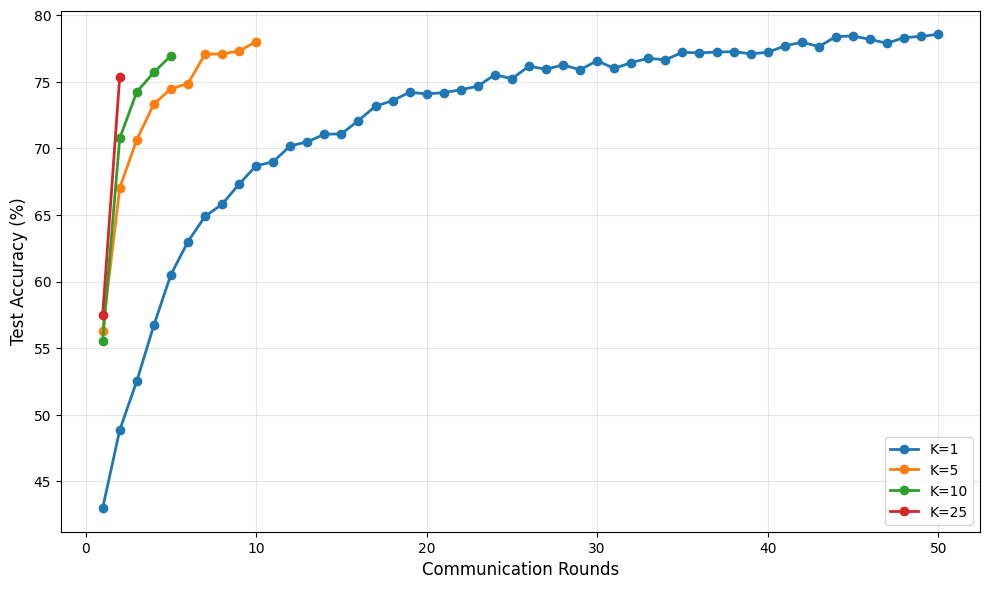

Figure saved to ./results/task2_varying_K_loss.png


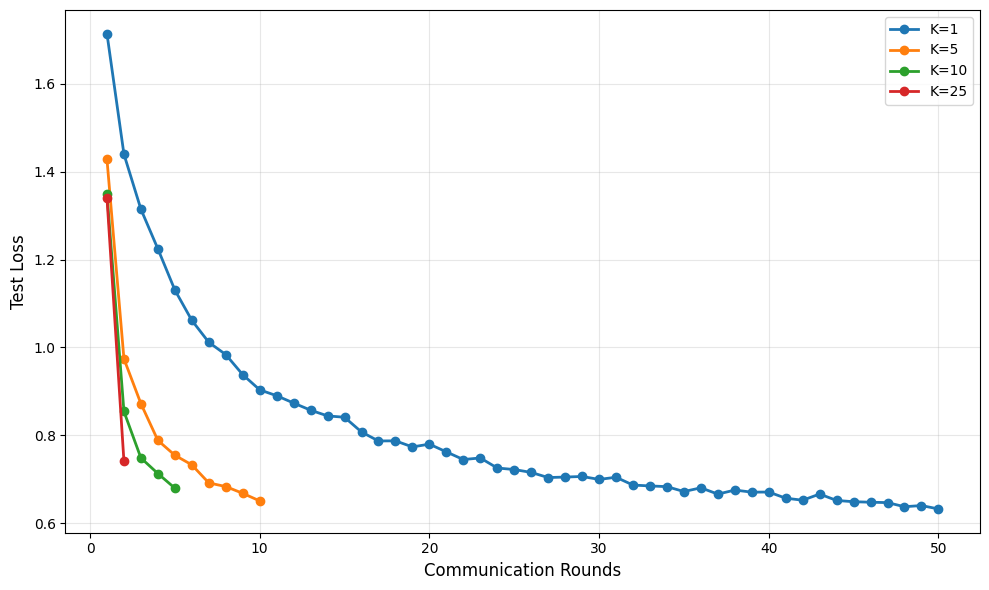

Figure saved to ./results/task2_varying_K_divergence.png


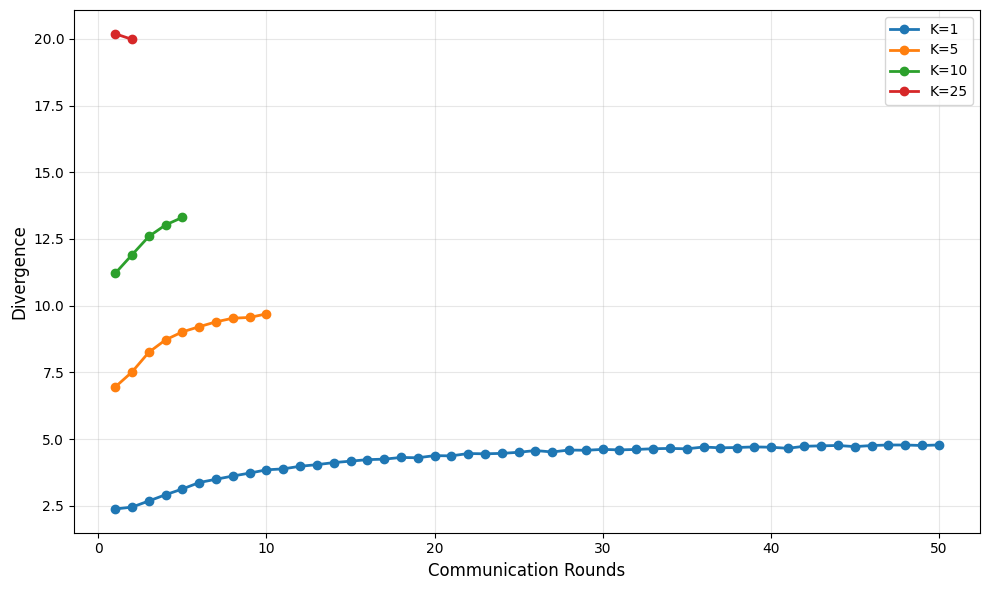

In [5]:
# Save experiment 1 results
save_results(results_varying_K, 'task2_varying_K')

# Plot results
plot_comparison(results_varying_K, metric='test_accuracy', title=None, save_path='./results/task2_varying_K.png')
plot_comparison(results_varying_K, metric='test_loss', save_path='./results/task2_varying_K_loss.png')
plot_comparison(results_varying_K, metric='divergence', save_path='./results/task2_varying_K_divergence.png')

## Experiment 2: Varying client sampling fraction

In [6]:
print("\n" + "="*80)
print("EXPERIMENT 2: Varying Client Sampling Fraction")
print("="*80)

sampling_fractions = [1.0, 0.6, 0.4]  # 100%, 60%, 40% of clients
FIXED_K = 1  # Use fixed K for this experiment
results_varying_sampling = {}

for fraction in sampling_fractions:
    print(f"\n--- Training with {int(fraction*100)}% client sampling ---")
    start_time = time.time()

    # Initialize model
    model = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])

    # Create clients
    clients = [Client(client_id=i, data_loader=client_loaders[i],
                     model=model, device=CONFIG['device'])
              for i in range(CONFIG['num_clients'])]

    # Create server
    server = Server(global_model=model, clients=clients,
                   test_loader=test_loader, device=CONFIG['device'])

    # Train
    history = server.train(
        num_rounds=CONFIG['num_rounds'][FIXED_K],
        local_epochs=FIXED_K,
        lr=CONFIG['lr'],
        client_fraction=fraction,
        momentum=CONFIG['momentum'],
        verbose=True
    )

    end_time = time.time()
    duration = end_time - start_time

    # Save results
    results_varying_sampling[f'{int(fraction*100)}% clients'] = {
        'history': history,
        'config': {**CONFIG, 'local_epochs': FIXED_K, 'client_fraction': fraction},
        'time_minutes': round(duration / 60, 2)
    }

    print(f"\nFinal accuracy with {int(fraction*100)}% sampling: {history['test_accuracy'][-1]:.2f}%")
    print(f"Training time: {duration/60:.2f} minutes")


EXPERIMENT 2: Varying Client Sampling Fraction

--- Training with 100% client sampling ---
Round 1/50 | Test Acc: 41.54% | Test Loss: 1.7280 | Train Loss: 1.9764 | Divergence: 2.3900
Round 2/50 | Test Acc: 48.51% | Test Loss: 1.4393 | Train Loss: 1.7085 | Divergence: 2.4110
Round 3/50 | Test Acc: 53.37% | Test Loss: 1.3091 | Train Loss: 1.5764 | Divergence: 2.6186
Round 4/50 | Test Acc: 57.17% | Test Loss: 1.2035 | Train Loss: 1.4758 | Divergence: 2.8649
Round 5/50 | Test Acc: 59.77% | Test Loss: 1.1410 | Train Loss: 1.3953 | Divergence: 3.1033
Round 6/50 | Test Acc: 62.39% | Test Loss: 1.0791 | Train Loss: 1.3377 | Divergence: 3.3036
Round 7/50 | Test Acc: 63.99% | Test Loss: 1.0305 | Train Loss: 1.2832 | Divergence: 3.4749
Round 8/50 | Test Acc: 65.70% | Test Loss: 0.9798 | Train Loss: 1.2398 | Divergence: 3.5887
Round 9/50 | Test Acc: 66.66% | Test Loss: 0.9488 | Train Loss: 1.2022 | Divergence: 3.7029
Round 10/50 | Test Acc: 67.49% | Test Loss: 0.9299 | Train Loss: 1.1666 | Diverg

Results saved to ./results/task2_varying_sampling.json
Figure saved to ./results/task2_varying_sampling.png


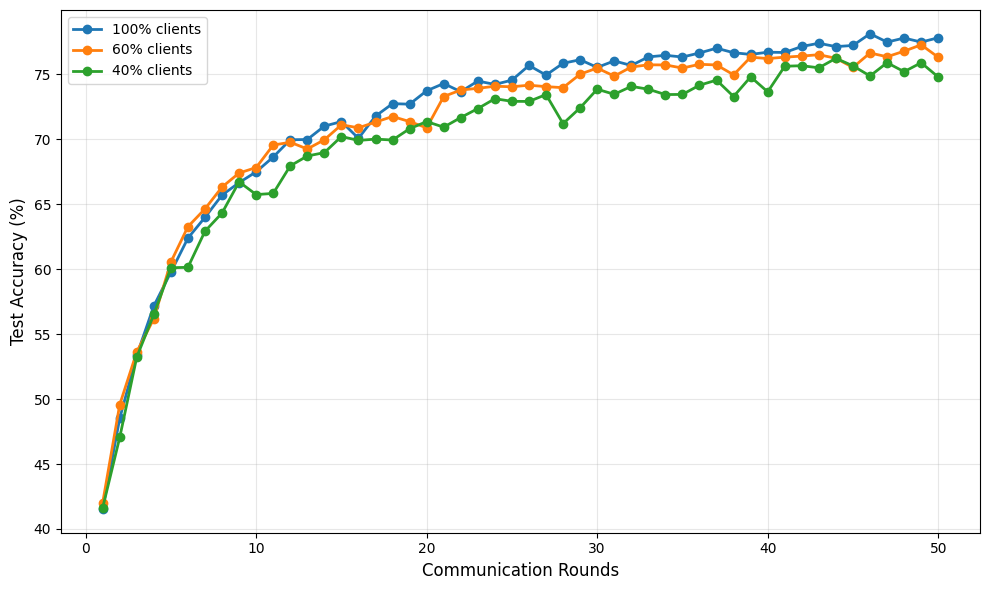

Figure saved to ./results/task2_varying_sampling_loss.png


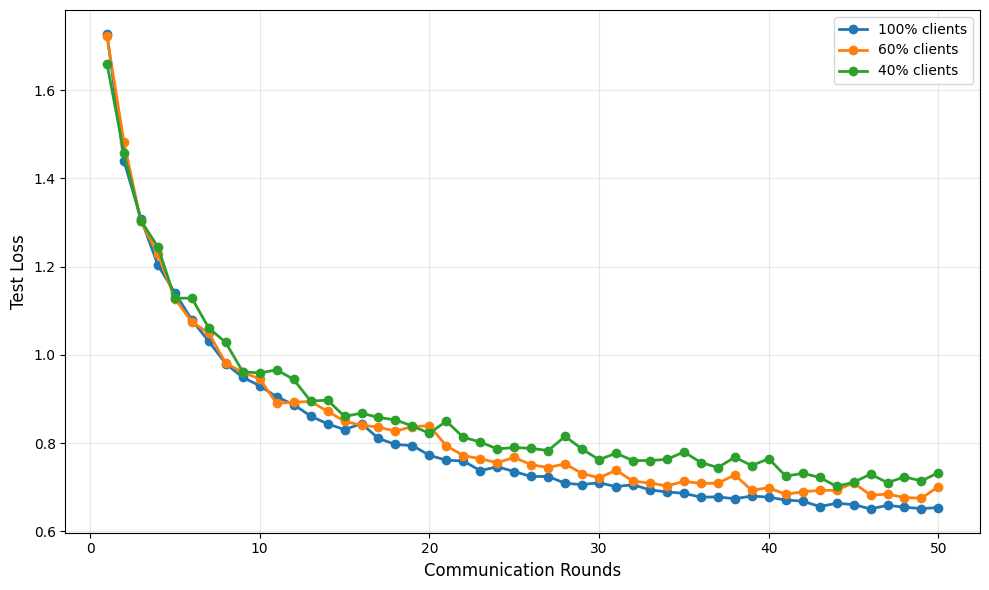

Figure saved to ./results/task2_varying_sampling_divergence.png


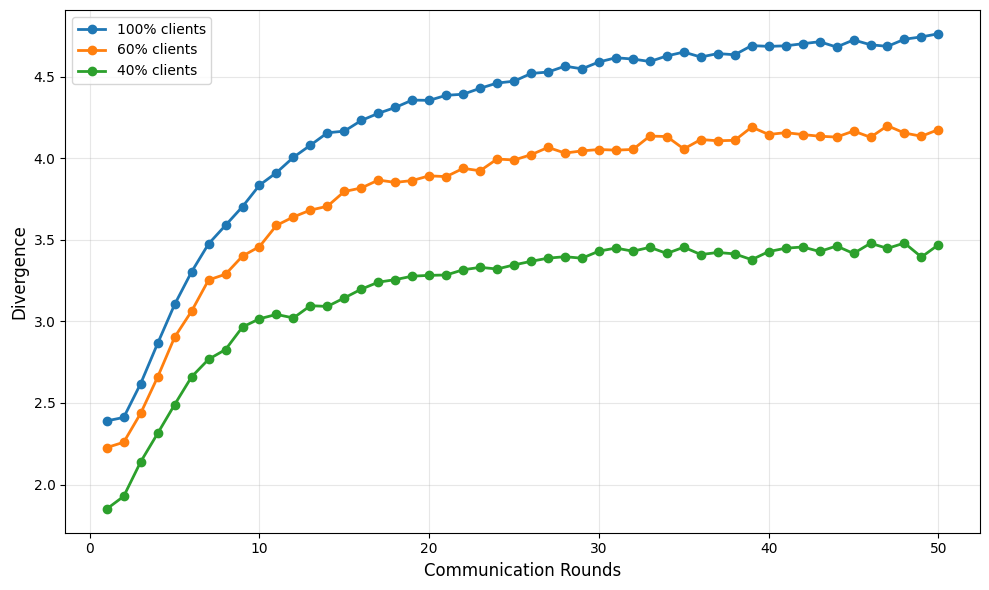

In [7]:
# Save experiment 2 results
save_results(results_varying_sampling, 'task2_varying_sampling')

# Plot results
plot_comparison(results_varying_sampling, metric='test_accuracy', title=None, save_path='./results/task2_varying_sampling.png')
plot_comparison(results_varying_sampling, metric='test_loss', save_path='./results/task2_varying_sampling_loss.png')
plot_comparison(results_varying_sampling, metric='divergence', save_path='./results/task2_varying_sampling_divergence.png')


## 3. Analysis

In [8]:
# Summary and Analysis
print("\n" + "="*80)
print("TASK 2: SUMMARY AND ANALYSIS")
print("="*80)

print("\n--- Experiment 1: Varying K ---")
print_summary(results_varying_K)

print("\n--- Experiment 2: Varying Client Sampling ---")
print_summary(results_varying_sampling)

print("\nKey Observations:")
print("1. Local Epochs (K):")
print("   - Higher K reduces communication rounds but may cause instability")
print("   - Trade-off between communication efficiency and convergence stability")

print("\n2. Client Sampling:")
print("   - Full participation (100%) gives best accuracy")
print("   - Partial sampling reduces communication but may slow convergence")
print("   - Useful for bandwidth-constrained scenarios")


TASK 2: SUMMARY AND ANALYSIS

--- Experiment 1: Varying K ---

EXPERIMENTAL RESULTS SUMMARY

K=1:
  Final Test Accuracy: 78.56%
  Best Test Accuracy:  78.56%
  Final Test Loss:     0.6326
  Final Divergence: 4.7830
  Average Divergence: 4.2524
  Configuration:
    dataset: cifar10
    num_clients: 5
    num_rounds: {1: 50, 5: 10, 10: 5, 25: 2}
    batch_size: 32
    lr: 0.01
    momentum: 0.9
    device: cuda
    local_epochs: 1
    client_fraction: 1.0

K=5:
  Final Test Accuracy: 78.00%
  Best Test Accuracy:  78.00%
  Final Test Loss:     0.6509
  Final Divergence: 9.6949
  Average Divergence: 8.7868
  Configuration:
    dataset: cifar10
    num_clients: 5
    num_rounds: {1: 50, 5: 10, 10: 5, 25: 2}
    batch_size: 32
    lr: 0.01
    momentum: 0.9
    device: cuda
    local_epochs: 5
    client_fraction: 1.0

K=10:
  Final Test Accuracy: 76.95%
  Best Test Accuracy:  76.95%
  Final Test Loss:     0.6799
  Final Divergence: 13.3096
  Average Divergence: 12.4106
  Configuration:
   

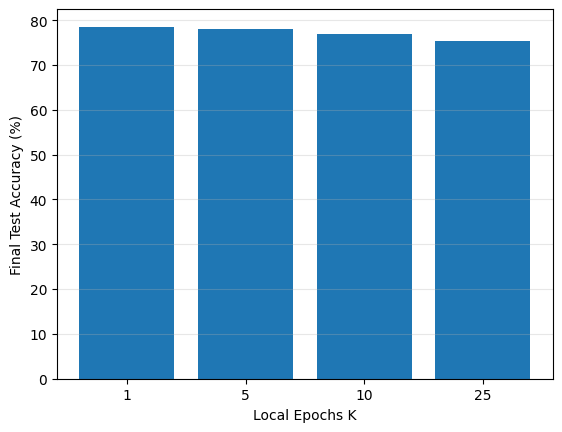

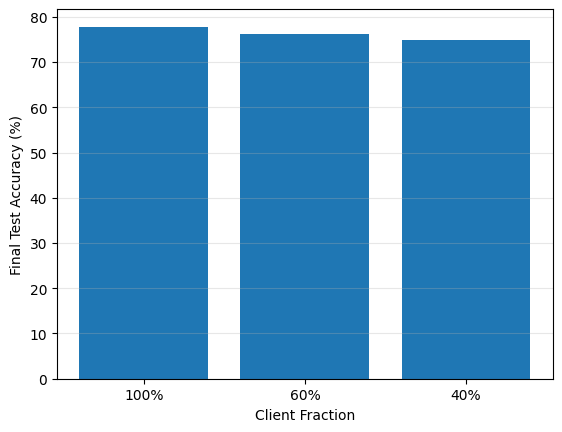

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt

# Varying K
Ks = [1, 5, 10, 25]
final_acc = [results_varying_K[f'K={k}']['history']['test_accuracy'][-1] for k in Ks]

plt.bar([str(k) for k in Ks], final_acc)
plt.xlabel('Local Epochs K')
plt.ylabel('Final Test Accuracy (%)')
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.savefig('./results/final_acc_vs_K.png', dpi=300)

# Varying client fraction
fractions = [1.0, 0.6, 0.4]
final_acc_sampling = [results_varying_sampling[f'{int(f*100)}% clients']['history']['test_accuracy'][-1] for f in fractions]

plt.bar([f"{int(f*100)}%" for f in fractions], final_acc_sampling)
plt.xlabel('Client Fraction')
plt.ylabel('Final Test Accuracy (%)')
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.savefig('./results/final_acc_vs_fraction.png', dpi=300)

In [10]:
# Save combined results
all_results_task2 = {
    'varying_K': results_varying_K,
    'varying_sampling': results_varying_sampling,
    'config': CONFIG
}
save_results(all_results_task2, 'task2_complete')

print("\n" + "="*80)
print("TASK 2 COMPLETE - All results saved!")
print("="*80)

Results saved to ./results/task2_complete.json

TASK 2 COMPLETE - All results saved!


In [11]:
!zip -r results.zip results/

  adding: results/ (stored 0%)
  adding: results/task2_varying_sampling.json (deflated 84%)
  adding: results/task2_complete.json (deflated 87%)
  adding: results/task2_varying_K_divergence.png (deflated 24%)
  adding: results/final_acc_vs_K.png (deflated 97%)
  adding: results/task2_varying_K.json (deflated 85%)
  adding: results/task2_varying_K.png (deflated 17%)
  adding: results/task2_varying_K_loss.png (deflated 17%)
  adding: results/task2_varying_sampling_divergence.png (deflated 14%)
  adding: results/task2_varying_sampling_loss.png (deflated 14%)
  adding: results/final_acc_vs_fraction.png (deflated 97%)
  adding: results/task2_varying_sampling.png (deflated 12%)
